In [1]:


import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt


In [2]:


(ds_train, ds_val), ds_info = tfds.load(
    'cats_vs_dogs',
    split=['train[:5%]', 'train[5%:7%]'],
    as_supervised=True,
    with_info=True
)


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cats_vs_dogs/incomplete.XUU65Z_4.0.1/cats_vs_dogs-train.tfrecord*...:   0%…

Dataset cats_vs_dogs downloaded and prepared to /root/tensorflow_datasets/cats_vs_dogs/4.0.1. Subsequent calls will reuse this data.


In [4]:
#blockfor changing img_size
IMG_SIZE = (128, 128)
BATCH_SIZE = 32
EPOCHS = 5

In [5]:
def preprocess(image, label):
    image = tf.image.resize(image, IMG_SIZE)
    image = image / 255.0
    return image, label

train_ds = ds_train.map(preprocess).batch(BATCH_SIZE)
val_ds = ds_val.map(preprocess).batch(BATCH_SIZE)


In [6]:
base_model = tf.keras.applications.VGG16(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [7]:

x = layers.Flatten()(base_model.output)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)
output = layers.Dense(2, activation='softmax')(x)
model = models.Model(inputs=base_model.input, outputs=output)



In [8]:

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS)



Epoch 1/5
37/37 ━━━━━━━━━━━━━━━━━━━━ 22s 364ms/step - accuracy: 0.6573 - loss: 0.9442 - val_accuracy: 0.8258 - val_loss: 0.3599
Epoch 2/5
37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 94ms/step - accuracy: 0.8797 - loss: 0.2717 - val_accuracy: 0.8559 - val_loss: 0.3223
Epoch 3/5
37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 98ms/step - accuracy: 0.9109 - loss: 0.2241 - val_accuracy: 0.8753 - val_loss: 0.3012
Epoch 4/5
37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 99ms/step - accuracy: 0.9375 - loss: 0.1824 - val_accuracy: 0.8366 - val_loss: 0.3522
Epoch 5/5
37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 95ms/step - accuracy: 0.9514 - loss: 0.1276 - val_accuracy: 0.8194 - val_loss: 0.3676


In [9]:
val_loss, val_acc = model.evaluate(val_ds)
print(f"Validation Accuracy: {val_acc*100:.2f}%")


15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step - accuracy: 0.8292 - loss: 0.3474
Validation Accuracy: 81.94%


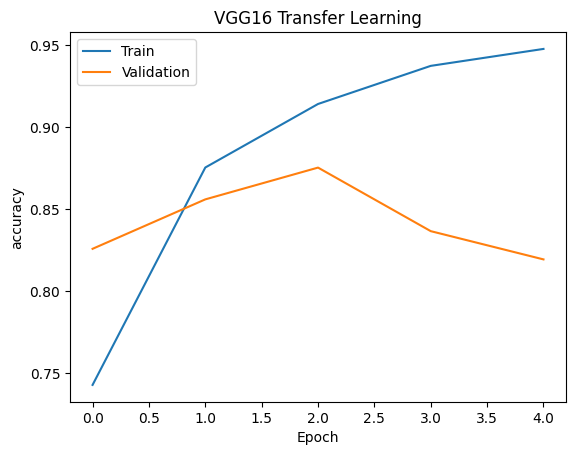

In [11]:

plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('VGG16 Transfer Learning')
plt.xlabel('Epoch')
plt.ylabel('accuracy')
plt.legend()
plt.show()
